# Food-20 Image Classification Challenge

**Release:** May 22, 2026  
**Deadline:** May 28, 2026  
**Recommended environment:** Google Colab with GPU runtime

In this competition you will build an image classifier for 20 food categories. This notebook is a starting template: it contains the common setup, data download, sanity checks, and submission validation. It does **not** contain a working baseline model. You are expected to design, train, compare, and analyze your own models.

To get the maximum score, your submission should include:
- one valid Kaggle submission
- one reproducible notebook or code file
- at least **three meaningful experiments on model/backbone choices**
- at least **three meaningful experiments on the data or training setup**
- a small experiment table with validation scores
- error analysis on validation mistakes
- final `submission.csv` generated by your code

Important rules:
- Use only the provided training data for training.
- Do not manually label test images.
- Do not search for exact test images online to recover labels.
- Do not use hidden labels, Food-101 metadata, or original split information to identify test labels.
- AI tools are allowed, but you must understand and be able to explain your final solution.

Leaderboard score is only part of the grade. Your comparison, ablation, error analysis, and reproducibility also matter.

Grading grid:

| Component | Weight |
|---|---:|
| Private leaderboard score | 50% |
| Model comparison / ablation | 30% |
| Error analysis | 10% |
| Reproducible notebook/code | 10% |

Private leaderboard thresholds:

| Private score | Leaderboard points |
|---:|---:|
| Valid submission below 0.35 | up to 10 / 50 |
| `>= 0.35` | 20 / 50 |
| `>= 0.65` | 30 / 50 |
| `>= 0.78` | 40 / 50 |
| `>= 0.86` | 50 / 50 |
| `>= 0.88` | bonus consideration |

## 0. Setup

The setup below is provided because it should be almost identical for everyone. You may modify paths and the competition slug if needed.

In [2]:
# If you are running in Colab, this installs the Kaggle API client.
# You can skip this cell if Kaggle is already installed.
!pip -q install kaggle


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
from pathlib import Path
import os
import random
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.optim as optim
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


## 1. Download the Competition Data

Before running this section:

1. Accept the private competition invitation in your browser.
2. Create a Kaggle API token from your Kaggle account settings.
3. Upload `kaggle.json` when the notebook asks for it.
4. Replace `COMPETITION_SLUG` if your competition URL uses a different slug.

The invitation token is not the same thing as the competition slug.

In [4]:
# Upload kaggle.json in Colab if needed.
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

kaggle_dir = Path.home() / '.kaggle'
kaggle_dir.mkdir(exist_ok=True)

if not (kaggle_dir / 'kaggle.json').exists():
    if not IN_COLAB:
        raise FileNotFoundError(
            'Place kaggle.json at ~/.kaggle/kaggle.json, or run this notebook in Colab.'
        )
    uploaded = files.upload()
    if 'kaggle.json' not in uploaded:
        raise RuntimeError('Please upload kaggle.json from your Kaggle account settings.')
    shutil.move('kaggle.json', kaggle_dir / 'kaggle.json')
    os.chmod(kaggle_dir / 'kaggle.json', 0o600)

print('Kaggle API token is ready.')

Kaggle API token is ready.


In [5]:
COMPETITION_SLUG = 'harbour-space-food-20-image-classification-challenge'
DATA_DIR = Path('/content/food20_data') if IN_COLAB else Path('food20_data')
DATA_DIR.mkdir(parents=True, exist_ok=True)

!kaggle competitions download -c {COMPETITION_SLUG} -p {DATA_DIR}

zip_files = sorted(DATA_DIR.glob('*.zip'))
if not zip_files:
    raise RuntimeError('No zip files were downloaded. Check the competition slug and API access.')

for zip_path in zip_files:
    shutil.unpack_archive(str(zip_path), str(DATA_DIR))

print('Downloaded files:')
for path in sorted(DATA_DIR.iterdir()):
    print('-', path.name)

harbour-space-food-20-image-classification-challenge.zip: Skipping, found more recently modified local copy (use --force to force download)
Downloaded files:
- harbour-space-food-20-image-classification-challenge.zip
- label_map.csv
- sample_submission.csv
- test.csv
- test_images
- train.csv
- train_images


## 2. Load Metadata and Check the Files

This code only reads metadata and checks that the dataset is present. It does not solve the modeling task.

In [6]:
TRAIN_CSV = DATA_DIR / 'train.csv'
TEST_CSV = DATA_DIR / 'test.csv'
LABEL_MAP_CSV = DATA_DIR / 'label_map.csv'
SAMPLE_SUBMISSION_CSV = DATA_DIR / 'sample_submission.csv'
TRAIN_IMAGES_DIR = DATA_DIR
TEST_IMAGES_DIR = DATA_DIR / 'test_images'

required_paths = [
    TRAIN_CSV, TEST_CSV, LABEL_MAP_CSV, SAMPLE_SUBMISSION_CSV,
    TRAIN_IMAGES_DIR, TEST_IMAGES_DIR,
]
missing = [str(path) for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError('Missing expected files:\n' + '\n'.join(missing))

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
label_map_df = pd.read_csv(LABEL_MAP_CSV)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_CSV)

print('train_df:', train_df.shape)
print('test_df:', test_df.shape)
print('label_map_df:', label_map_df.shape)
print('sample_submission:', sample_submission.shape)

display(train_df.head())
display(test_df.head())
display(label_map_df.head())

train_df: (10000, 3)
test_df: (5000, 2)
label_map_df: (20, 2)
sample_submission: (5000, 2)


,id,filename,label
0,train_000998,train_images/train_000998.jpg,baby_back_ribs
1,train_001027,train_images/train_001027.jpg,baklava
2,train_005261,train_images/train_005261.jpg,french_fries
3,train_005657,train_images/train_005657.jpg,hamburger
4,train_006691,train_images/train_006691.jpg,lasagna


,id,filename
0,test_004393,test_images/test_004393.jpg
1,test_000519,test_images/test_000519.jpg
2,test_000856,test_images/test_000856.jpg
3,test_002629,test_images/test_002629.jpg
4,test_004853,test_images/test_004853.jpg


,label,class_index
0,apple_pie,0
1,baby_back_ribs,1
2,baklava,2
3,beef_carpaccio,3
4,caesar_salad,4


In [7]:
label_names = sorted(train_df['label'].unique().tolist())
label_to_id = {label: idx for idx, label in enumerate(label_names)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

print('Number of classes:', len(label_names))
print(label_names)

class_counts = train_df['label'].value_counts().sort_index()
display(class_counts.to_frame('count'))

assert len(label_names) == 20, 'Expected 20 classes.'
assert set(sample_submission.columns) == {'id', 'label'}, sample_submission.columns.tolist()
assert len(sample_submission) == len(test_df), 'sample_submission and test.csv should have the same number of rows.'
print('Basic checks passed.')

Number of classes: 20
['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'caesar_salad', 'cheesecake', 'chicken_curry', 'chocolate_cake', 'donuts', 'dumplings', 'french_fries', 'hamburger', 'ice_cream', 'lasagna', 'omelette', 'pizza', 'ramen', 'steak', 'sushi', 'tacos']


,count
label,
apple_pie,500
baby_back_ribs,500
baklava,500
beef_carpaccio,500
caesar_salad,500
cheesecake,500
chicken_curry,500
chocolate_cake,500
donuts,500


Basic checks passed.


## 3. Inspect Images

Use this section to understand the data before modeling. You may extend it with your own visualizations.

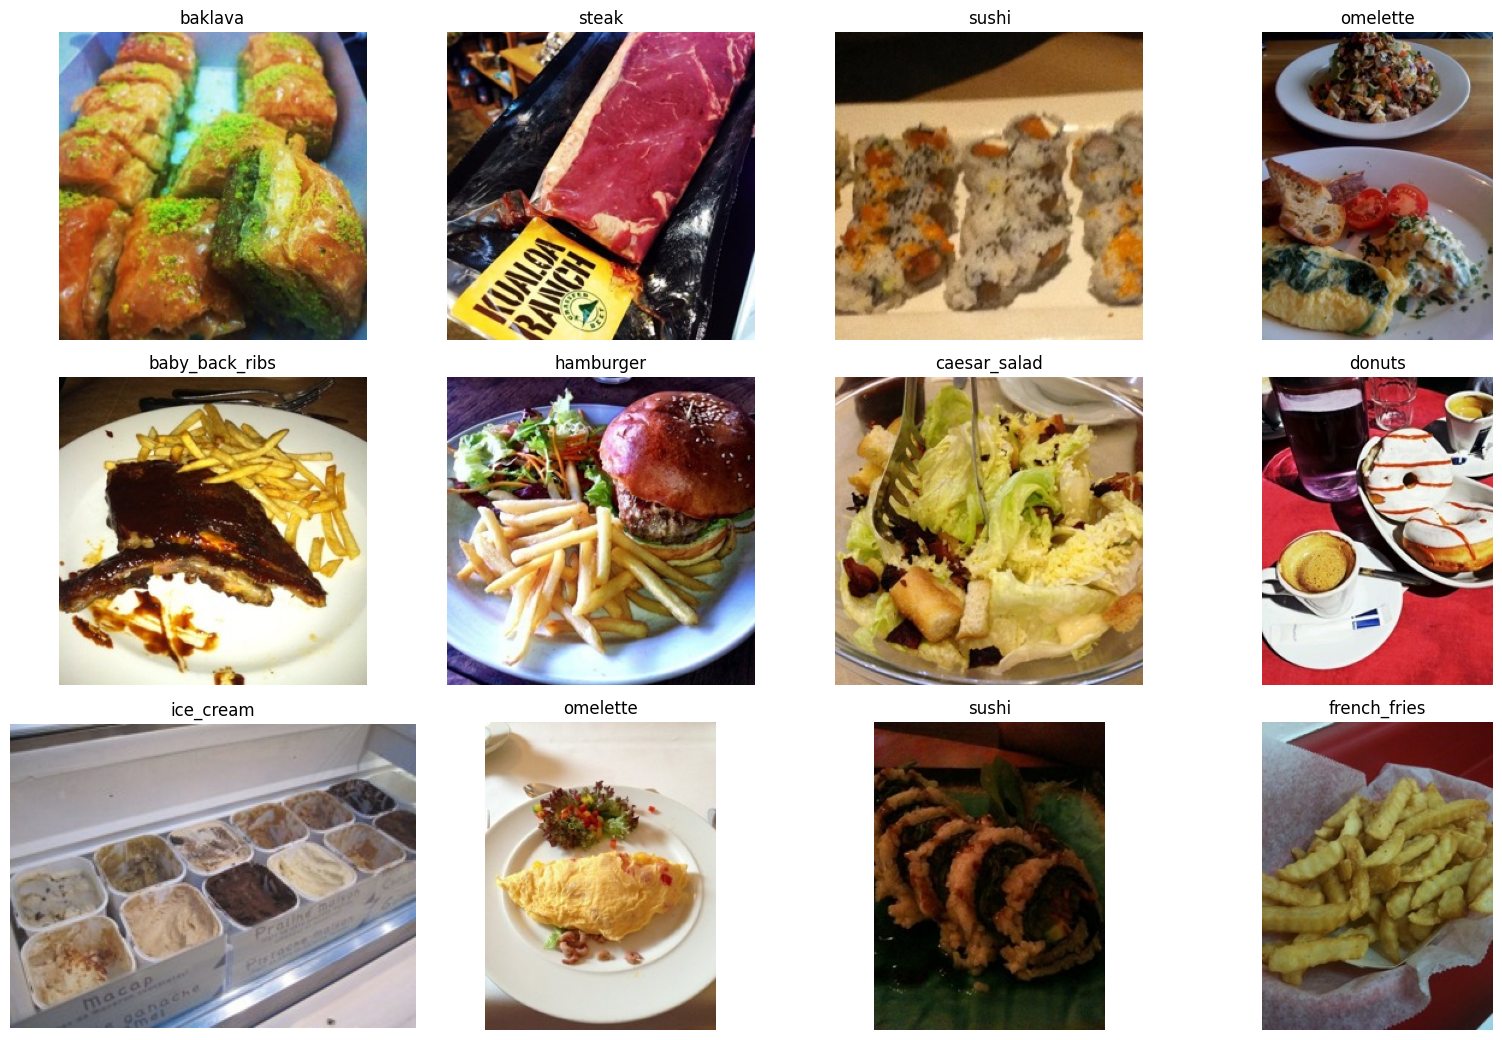

In [8]:
def load_image_from_row(row, images_dir):
    return Image.open(images_dir / row['filename']).convert('RGB')

def show_examples(df, images_dir, n=12, seed=SEED):
    sample = df.sample(n=min(n, len(df)), random_state=seed).reset_index(drop=True)
    cols = 4
    rows = int(np.ceil(len(sample) / cols))
    plt.figure(figsize=(4 * cols, 3.5 * rows))
    for i, row in sample.iterrows():
        image = load_image_from_row(row, images_dir)
        plt.subplot(rows, cols, i + 1)
        plt.imshow(image)
        title = row.get('label', row['id'])
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()

show_examples(train_df, TRAIN_IMAGES_DIR, n=12)

## 4. Create Your Validation Split

Do not tune your model only on the public leaderboard. Create your own validation split from `train.csv`.

Requirements:
- Use a stratified split so every class is represented.
- Keep the split fixed across experiments.
- Report validation accuracy for every experiment in your table.

Suggested variables to create:
- `train_part`
- `val_part`

You may use `sklearn.model_selection.train_test_split`, but the implementation is up to you.

In [9]:
# TODO: create a stratified train/validation split.
#
# Hints:
# from sklearn.model_selection import train_test_split
# train_part, val_part = train_test_split(..., stratify=train_df['label'], random_state=SEED)
from sklearn.model_selection import train_test_split
train_part, val_part = train_test_split(
    train_df, 
    test_size=0.2, 
    stratify=train_df['label'], 
    random_state=SEED
)

train_part = train_part.reset_index(drop=True)
val_part = val_part.reset_index(drop=True)

print("--- Data Split Successfully ---")
print(f"Total training samples  : {len(train_part)} images")
print(f"Total validation samples: {len(val_part)} images")

#raise NotImplementedError('Create your train/validation split here.')

--- Data Split Successfully ---
Total training samples  : 8000 images
Total validation samples: 2000 images


## 5. Build Datasets and DataLoaders

Design your own PyTorch dataset and transforms.

Requirements:
- Training transforms should be appropriate for image classification.
- Validation/test transforms should be deterministic.
- The validation set must not use random augmentation.

Things to experiment with:
- image size;
- crop vs resize;
- horizontal flip;
- color jitter;
- normalization;
- stronger augmentation policies.

In [10]:
# TODO: implement dataset, transforms, and dataloaders.
#
# Suggested objects to create:
# train_dataset, val_dataset, test_dataset
# train_loader, val_loader, test_loader
#
# Keep this flexible: you will likely change transforms across experiments.

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class FoodDataset(Dataset):
    def __init__(self, df, img_dir, label_to_idx=None, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        self.label_to_idx = label_to_idx

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.img_dir / row['filename']
        image = Image.open(img_path).convert('RGB')

        if self.label_to_idx and 'label' in row:
            label = self.label_to_idx[row['label']]
        else:
            label = 0  
            
        if self.transform:
            image = self.transform(image)
            
        return image, label


label_to_idx = dict(zip(label_map_df['label'], label_map_df['class_index']))

train_dataset = FoodDataset(df=train_part, img_dir=DATA_DIR, label_to_idx=label_to_idx, transform=train_transform)
val_dataset = FoodDataset(df=val_part, img_dir=DATA_DIR, label_to_idx=label_to_idx, transform=val_transform)
test_dataset = FoodDataset(df=test_df, img_dir=DATA_DIR, label_to_idx=label_to_idx, transform=val_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print("--- Datasets and DataLoaders successfully created ---")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")
#raise NotImplementedError('Build your Dataset and DataLoaders here.')

--- Datasets and DataLoaders successfully created ---
Train batches: 250 | Val batches: 63 | Test batches: 157


## 6. Model Experiments

You need at least **three meaningful experiments on model/backbone choices**.

Examples:
- small CNN from scratch;
- frozen pretrained CNN;
- partially fine-tuned pretrained CNN;
- ResNet vs EfficientNet;
- different model sizes.

Do not just change a variable name and call it a new experiment. Each experiment should test a real idea.

In [13]:
# TODO: define your model or model-building function.
#
# Suggested pattern:
# def build_model(...):
#     ...
#     return model
def build_model(model_name='cnn_scratch', num_classes=20):
    if model_name == 'baseline_mlp':
        model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 128 * 128, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
        print("Successfully built: Baseline MLP Model")
        
    elif model_name == 'cnn_scratch':
        model = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )
        print("Successfully built: Small CNN from scratch")
        
    elif model_name == 'pretrained_resnet':
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
        
        print("Successfully built: Pretrained ResNet18 (Fine-tuning)")
        
    else:
        raise ValueError(f"Unknown model name: {model_name}")
        
    return model.to(device)
model = build_model(model_name='baseline_mlp', num_classes=20)
#raise NotImplementedError('Define your model experiment here.')

Successfully built: Baseline MLP Model


## 7. Training and Validation

Write or reuse a training loop. Track both training and validation metrics.

Requirements:
- train loss;
- validation loss;
- validation accuracy;
- best checkpoint selection using validation accuracy or validation loss.

Suggested variables to create:
- `history` as a pandas DataFrame;
- `best_model_path`;
- `best_val_acc`.

In [ ]:
# TODO: implement training and validation.
#
# Suggested skeleton:
# for epoch in range(num_epochs):
#     # train one epoch
#     # validate
#     # save best checkpoint
#     pass

import torch.optim as optim
import torch.nn as nn
import pandas as pd

# 1. ประกาศสร้างโมเดลตัวแรกที่เราต้องการจะทดลอง (เริ่มเทรนด้วย Small CNN ที่เราเขียนฟังก์ชันสร้างไว้)
# หมายเหตุ: สามารถสลับชื่อเป็น 'baseline_mlp' หรือ 'pretrained_resnet' ในการทดลองถัดๆ ไปได้ครับ
model = build_model(model_name='cnn_scratch', num_classes=20)

# 2. กำหนดฟังก์ชันวัดความสูญเสีย (Criterion) และตัวปรับค่าน้ำหนัก (Optimizer)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# 3. สั่งรันกระบวนการเทรนผ่านฟังก์ชันสำเร็จรูปของอาจารย์
# สั่งเทรนสัก 10 - 15 Epochs กำลังดีสำหรับตรวจสอบระบบเบื้องต้นครับ
NUM_EPOCHS = 10

print("--- Starting Training Process ---")
history_list = fit_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=NUM_EPOCHS,
    device=device
)

# 4. แปลงข้อมูลประวัติการเทรนให้อยู่ในรูปของตาราง Pandas DataFrame ตามที่อาจารย์แนะนำ
history = pd.DataFrame(history_list)

print("\n--- Training Completed Successfully ---")
display(history.tail())
#raise NotImplementedError('Implement training and validation here.')

NotImplementedError: Implement training and validation here.

## 8. Experiment Log

Fill this table as you work. Add rows for every serious experiment.

| Experiment | Model/backbone | Data/training change | Image size | LR | Val acc | Public LB | Notes |
|---|---|---|---:|---:|---:|---:|---|
| 1 |  |  |  |  |  |  |  |
| 2 |  |  |  |  |  |  |  |
| 3 |  |  |  |  |  |  |  |
| 4 |  |  |  |  |  |  |  |
| 5 |  |  |  |  |  |  |  |
| 6 |  |  |  |  |  |  |  |

At minimum, you need:
- three meaningful model/backbone experiments;
- three meaningful data or training setup experiments.

## 9. Error Analysis

Use your validation set for error analysis.

Questions to answer:
- Which classes are most often confused?
- Show several validation images your model classified incorrectly.
- Are mistakes caused by similar visual appearance, poor lighting, viewpoint, occlusion, or label ambiguity?
- Which experiment changed the error pattern the most?

You may implement a confusion matrix and a visualization of misclassified examples.

In [ ]:
# TODO: collect validation predictions and perform error analysis.
#
# Ideas:
# - confusion matrix
# - most confused class pairs
# - grid of misclassified validation images

raise NotImplementedError('Add your error analysis here.')

## 10. Generate a Submission

After you choose your final model, predict labels for every row in `test.csv` and create `submission.csv`.

The helper below checks the file format, but it does not create predictions for you.

In [ ]:
def validate_submission(submission_df, test_df, valid_labels):
    required_columns = ['id', 'label']
    assert list(submission_df.columns) == required_columns, submission_df.columns.tolist()
    assert len(submission_df) == len(test_df), 'Wrong number of rows.'
    assert submission_df['id'].is_unique, 'Submission IDs must be unique.'
    assert set(submission_df['id']) == set(test_df['id']), 'Submission IDs must match test.csv.'
    bad_labels = sorted(set(submission_df['label']) - set(valid_labels))
    assert not bad_labels, f'Invalid labels found: {bad_labels[:10]}'
    assert not submission_df['label'].isna().any(), 'Missing labels found.'
    print('Submission format looks valid.')

# TODO: replace this with predictions from your trained model.
# final_predictions should be a list/array of labels, one per row in test_df.

final_predictions = None

if final_predictions is None:
    raise NotImplementedError('Create final_predictions using your trained model.')

submission = pd.DataFrame({
    'id': test_df['id'],
    'label': final_predictions,
})

validate_submission(submission, test_df, label_names)
submission.to_csv('submission.csv', index=False)
display(submission.head())
print('Saved submission.csv')

## 11. Final Checklist

Before submitting, check that:

- `submission.csv` has exactly the columns `id,label`;
- the number of rows equals `test.csv`;
- all predicted labels are valid class names;
- your notebook can reproduce the submission file;
- your experiment table contains at least six meaningful experiments total;
- your error analysis uses validation data, not the hidden test set;
- you can explain your final model and why you chose it.